# Análises auxiliares à construção de sistema automático de catalogação de matérias jornalísticas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

## Funções

In [2]:
def sample_multinomial(probabilities, n_trials, n_samples=1, seed=None):
    """
    Generate samples from a multinomial distribution.

    Parameters
    ----------
    probabilities : array-like
        Probabilities for each outcome. Must sum to 1.
    n_trials : int
        Number of trials in each multinomial sample.
    n_samples : int, optional
        Number of independent samples to generate.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    numpy.ndarray
        Array of shape (n_samples, n_categories), where each row
        contains the counts for the categories.
    """
    rng = np.random.default_rng(seed)

    probabilities = np.asarray(probabilities, dtype=float)

    # Validate probabilities
    if np.any(probabilities < 0):
        raise ValueError("Probabilities must be non-negative.")

    if not np.isclose(probabilities.sum(), 1.0):
        raise ValueError("Probabilities must sum to 1.")

    if n_trials < 0 or not isinstance(n_trials, int):
        raise ValueError("n_trials must be a non-negative integer.")

    return rng.multinomial(
        n=n_trials,
        pvals=probabilities,
        size=n_samples
    )

## Estimativa de tamanho de amostra

Vamos considerar uma distribuição multinomial para notícias. Para cada uma, os possíveis resultados são:
1. Não usar dados e não ser selecionada (0,0);
2. Não usar dados e ser selecionada (0,1);
3. Usar dados e não ser selecionada (1,0);
4. Usar dados e ser selecionada (1,1).

Vamos fazer um chute dessas probabilidades com base no que foi observado com trabalhos acadêmicos:

In [39]:
#                 00    01    10    11
probabilities = [0.87, 0.02, 0.02, 0.09]

precision = probabilities[3] / (probabilities[1] + probabilities[3])
precision_not = probabilities[0] / (probabilities[0] + probabilities[2])
print('Precision: {:.3f}'.format(precision))
print('Precision in no use: {:.3f}'.format(precision_not))

Precision: 0.818
Precision in no use: 0.978


In [51]:
# Loop over sample size (of news articles):
tsize_list = []
prec_list  = []
comp_list  = []
for tsize in range(100, 2100, 100):
    
    # Sample synthetic distributions:
    n_trials = tsize
    n_samples = 10000
    samples = sample_multinomial(probabilities, n_trials, n_samples, seed=42498)
    
    # Compute precision and recall:
    samples_df = pd.DataFrame(data=samples, columns=['n00', 'n01', 'n10', 'n11'])
    samples_df['prec'] = samples_df['n11'] / (samples_df['n01'] + samples_df['n11'])
    samples_df['comp'] = samples_df['n11'] / (samples_df['n10'] + samples_df['n11'])
    
    # Save results:
    tsize_list.append(tsize)
    prec_list.append(samples_df['prec'].std())
    comp_list.append(samples_df['comp'].std())


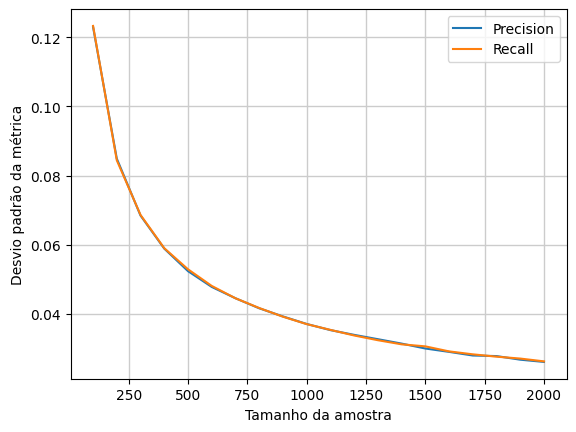

In [54]:
# Gráfico da relação entre incerteza nas métricas de performance e tamanho da amostra:
pl.plot(tsize_list, prec_list, label='Precision')
pl.plot(tsize_list, comp_list, label='Recall')
pl.xlabel('Tamanho da amostra')
pl.ylabel('Desvio padrão da métrica')
pl.legend()
pl.grid(linewidth=1, color='0.8')
#pl.xscale('log')
pl.show()

## Estimação de métrica baseline

In [2]:
from sklearn.metrics import accuracy_score

In [10]:
n_sample = 10000
p_use = 0.20
z_true = np.random.random(n_sample)
y_true = (z_true < p_use).astype(int)
y_pred = np.zeros_like(y_true)

In [11]:
accuracy_score(y_true, y_pred)

0.7984